In [1]:
# Cell 1: Install required packages
!pip install torch matplotlib numpy pandas scikit-learn

# Cell 2: Import libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
from IPython.display import clear_output

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Cell 3: Load the dataset
data_path = "/content/data_sampled.csv"
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nDataset statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

Using device: cpu
Dataset loaded successfully!
Dataset shape: (5000, 3)

First few rows:
       x       t          T
0  0.437   957.0   3.453235
1  0.292   506.0   2.301271
2  0.738  1629.0   4.308076
3  0.004   117.0   2.700479
4  0.531  2932.0  10.253374

Dataset columns: ['x', 't', 'T']

Dataset statistics:
                 x            t            T
count  5000.000000  5000.000000  5000.000000
mean      0.496261  1800.065000     7.055315
std       0.288331  1038.339305     4.822891
min       0.000000     0.000000     0.000000
25%       0.245000   907.500000     3.039438
50%       0.497000  1796.000000     6.359980
75%       0.744000  2700.250000    10.268674
max       1.000000  3600.000000    21.065569

Missing values: 0


Data points: 5000
x range: [0.0000, 1.0000] m
t range: [0.0000, 3600.0000] s
T range: [0.0000, 21.0656] °C


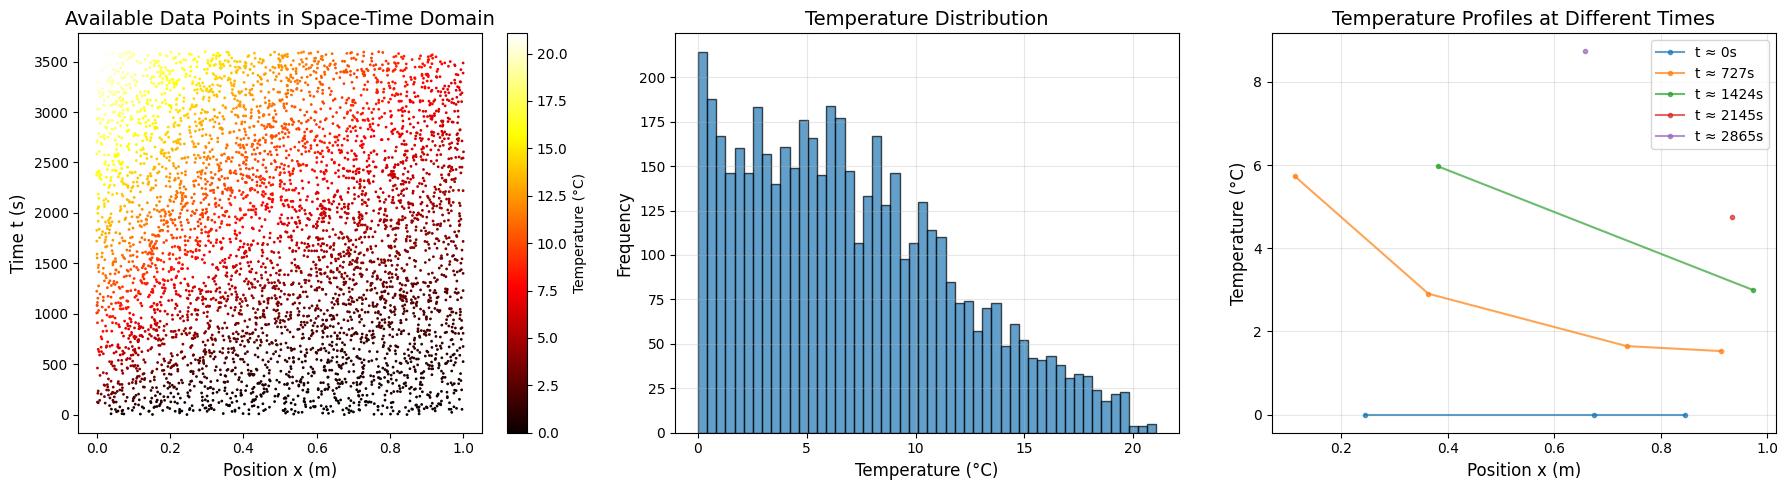

In [2]:
# Cell 4: Extract data and define physical parameters
# Assuming columns are: x, t, T (or similar)
# Adjust column names based on your CSV
x_data = df['x'].values if 'x' in df.columns else df.iloc[:, 0].values
t_data = df['t'].values if 't' in df.columns else df.iloc[:, 1].values
T_data = df['T'].values if 'T' in df.columns else df.iloc[:, 2].values

# Physical parameters for aluminum
alpha = 9.868e-5  # thermal diffusivity (m²/s)
k = 237.0  # thermal conductivity (W/m·K)
L = 1.0  # slab length (m)
q0 = 5000.0  # heat flux at left boundary (W/m²)

print(f"Data points: {len(x_data)}")
print(f"x range: [{x_data.min():.4f}, {x_data.max():.4f}] m")
print(f"t range: [{t_data.min():.4f}, {t_data.max():.4f}] s")
print(f"T range: [{T_data.min():.4f}, {T_data.max():.4f}] °C")

# Cell 5: Visualize the dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot of data points in space-time
ax = axes[0]
scatter = ax.scatter(x_data, t_data, c=T_data, s=1, cmap='hot')
ax.set_xlabel('Position x (m)', fontsize=12)
ax.set_ylabel('Time t (s)', fontsize=12)
ax.set_title('Available Data Points in Space-Time Domain', fontsize=14)
plt.colorbar(scatter, ax=ax, label='Temperature (°C)')

# Temperature distribution histogram
ax = axes[1]
ax.hist(T_data, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Temperature Distribution', fontsize=14)
ax.grid(True, alpha=0.3)

# Sample temperature profiles
ax = axes[2]
# Find unique time points and plot some profiles
unique_times = np.unique(t_data)
times_to_plot = unique_times[::len(unique_times)//5][:5]  # Plot 5 time slices

for t_val in times_to_plot:
    mask = np.abs(t_data - t_val) < 1.0  # Within 1 second
    x_subset = x_data[mask]
    T_subset = T_data[mask]

    # Sort by x for proper line plot
    sort_idx = np.argsort(x_subset)
    ax.plot(x_subset[sort_idx], T_subset[sort_idx], 'o-',
            label=f't ≈ {t_val:.0f}s', markersize=3, alpha=0.7)

ax.set_xlabel('Position x (m)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature Profiles at Different Times', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Cell 6: Prepare data for PINN training
def prepare_pinn_data(x_data, t_data, T_data,
                      n_collocation=10000,
                      n_boundary=100,
                      n_initial=100,
                      train_ratio=0.8):
    """
    Prepare data for PINN training:
    - Training data: sparse measurements
    - Collocation points: for PDE residual
    - Boundary points: for boundary conditions
    - Initial condition points: for IC
    """

    # Split sparse data into train and validation
    indices = np.arange(len(x_data))
    train_idx, val_idx = train_test_split(indices, train_size=train_ratio, random_state=42)

    x_train = x_data[train_idx]
    t_train = t_data[train_idx]
    T_train = T_data[train_idx]

    x_val = x_data[val_idx]
    t_val = t_data[val_idx]
    T_val = T_data[val_idx]

    # Generate collocation points (uniform random in domain)
    x_col = np.random.uniform(0, L, n_collocation)
    t_col = np.random.uniform(0, 3600, n_collocation)

    # Initial condition points (t=0)
    x_ic = np.random.uniform(0, L, n_initial)
    t_ic = np.zeros(n_initial)
    T_ic = np.zeros(n_initial)  # Initial temperature = 0°C

    # Boundary points
    # Left boundary (x=0)
    t_bc_left = np.random.uniform(0, 3600, n_boundary)
    x_bc_left = np.zeros(n_boundary)

    # Right boundary (x=L)
    t_bc_right = np.random.uniform(0, 3600, n_boundary)
    x_bc_right = np.ones(n_boundary) * L

    return {
        'x_train': x_train, 't_train': t_train, 'T_train': T_train,
        'x_val': x_val, 't_val': t_val, 'T_val': T_val,
        'x_col': x_col, 't_col': t_col,
        'x_ic': x_ic, 't_ic': t_ic, 'T_ic': T_ic,
        'x_bc_left': x_bc_left, 't_bc_left': t_bc_left,
        'x_bc_right': x_bc_right, 't_bc_right': t_bc_right
    }

# Prepare all data
pinn_data = prepare_pinn_data(x_data, t_data, T_data,
                              n_collocation=10000,
                              n_boundary=200,
                              n_initial=200,
                              train_ratio=0.8)

print("Data preparation complete!")
print(f"Training points: {len(pinn_data['x_train'])}")
print(f"Validation points: {len(pinn_data['x_val'])}")
print(f"Collocation points: {len(pinn_data['x_col'])}")
print(f"Initial condition points: {len(pinn_data['x_ic'])}")
print(f"Boundary points (each): {len(pinn_data['x_bc_left'])}")

Data preparation complete!
Training points: 4000
Validation points: 1000
Collocation points: 10000
Initial condition points: 200
Boundary points (each): 200


In [4]:
# Cell 7: Define Physics-Informed Neural Network
class PINN(nn.Module):
    def __init__(self, layers=[2, 64, 64, 64, 64, 1], activation='tanh'):
        super(PINN, self).__init__()

        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

        # Activation function
        if activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Tanh()

        # Initialize weights using Xavier initialization
        self.init_weights()

    def init_weights(self):
        for m in self.layers:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        # Concatenate inputs
        inputs = torch.cat([x, t], dim=1)

        # Pass through hidden layers
        out = inputs
        for i, layer in enumerate(self.layers[:-1]):
            out = self.activation(layer(out))

        # Output layer (no activation)
        out = self.layers[-1](out)

        return out

# Cell 8: Initialize the model
model = PINN(layers=[2, 64, 64, 64, 64, 1], activation='tanh').to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Total parameters: 12,737

Model architecture:
PINN(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
  (activation): Tanh()
)


In [5]:
# Cell 9: Define loss functions (CORRECTED)
def compute_pde_residual(model, x, t, alpha):
    """
    Compute PDE residual: ∂T/∂t - α * ∂²T/∂x²
    """
    x = x.requires_grad_(True)
    t = t.requires_grad_(True)

    T = model(x, t)

    # First derivatives
    T_t = torch.autograd.grad(T, t, grad_outputs=torch.ones_like(T),
                              create_graph=True, retain_graph=True)[0]
    T_x = torch.autograd.grad(T, x, grad_outputs=torch.ones_like(T),
                              create_graph=True, retain_graph=True)[0]

    # Second derivative
    T_xx = torch.autograd.grad(T_x, x, grad_outputs=torch.ones_like(T_x),
                               create_graph=True, retain_graph=True)[0]

    # PDE residual
    residual = T_t - alpha * T_xx

    return residual, T_x

def compute_bc_left(model, x, t, k, q0):
    """
    Left boundary condition: -k * ∂T/∂x = q0
    NORMALIZED VERSION
    """
    x = x.requires_grad_(True)
    T = model(x, t)

    T_x = torch.autograd.grad(T, x, grad_outputs=torch.ones_like(T),
                              create_graph=True, retain_graph=True)[0]

    # CRITICAL FIX: Normalize by q0 to keep loss scale reasonable
    flux_predicted = -k * T_x
    bc_residual = (flux_predicted - q0) / q0

    return bc_residual

def compute_bc_right(model, x, t):
    """
    Right boundary condition: ∂T/∂x = 0 (insulated)
    """
    x = x.requires_grad_(True)
    T = model(x, t)

    T_x = torch.autograd.grad(T, x, grad_outputs=torch.ones_like(T),
                              create_graph=True, retain_graph=True)[0]

    return T_x

def compute_loss(model, data, alpha, k, q0, weights):
    """
    Compute total loss = weighted sum of all loss components
    """
    # Convert to tensors
    x_train = torch.FloatTensor(data['x_train']).reshape(-1, 1).to(device)
    t_train = torch.FloatTensor(data['t_train']).reshape(-1, 1).to(device)
    T_train = torch.FloatTensor(data['T_train']).reshape(-1, 1).to(device)

    x_col = torch.FloatTensor(data['x_col']).reshape(-1, 1).to(device)
    t_col = torch.FloatTensor(data['t_col']).reshape(-1, 1).to(device)

    x_ic = torch.FloatTensor(data['x_ic']).reshape(-1, 1).to(device)
    t_ic = torch.FloatTensor(data['t_ic']).reshape(-1, 1).to(device)
    T_ic = torch.FloatTensor(data['T_ic']).reshape(-1, 1).to(device)

    x_bc_left = torch.FloatTensor(data['x_bc_left']).reshape(-1, 1).to(device)
    t_bc_left = torch.FloatTensor(data['t_bc_left']).reshape(-1, 1).to(device)

    x_bc_right = torch.FloatTensor(data['x_bc_right']).reshape(-1, 1).to(device)
    t_bc_right = torch.FloatTensor(data['t_bc_right']).reshape(-1, 1).to(device)

    # Data loss (MSE on sparse measurements)
    T_pred_train = model(x_train, t_train)
    loss_data = torch.mean((T_pred_train - T_train)**2)

    # PDE residual loss
    pde_residual, _ = compute_pde_residual(model, x_col, t_col, alpha)
    loss_pde = torch.mean(pde_residual**2)

    # Initial condition loss
    T_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((T_pred_ic - T_ic)**2)

    # Boundary condition losses
    bc_left_residual = compute_bc_left(model, x_bc_left, t_bc_left, k, q0)
    loss_bc_left = torch.mean(bc_left_residual**2)

    bc_right_residual = compute_bc_right(model, x_bc_right, t_bc_right)
    loss_bc_right = torch.mean(bc_right_residual**2)

    # Total weighted loss
    total_loss = (weights['data'] * loss_data +
                  weights['pde'] * loss_pde +
                  weights['ic'] * loss_ic +
                  weights['bc_left'] * loss_bc_left +
                  weights['bc_right'] * loss_bc_right)

    losses = {
        'total': total_loss.item(),
        'data': loss_data.item(),
        'pde': loss_pde.item(),
        'ic': loss_ic.item(),
        'bc_left': loss_bc_left.item(),
        'bc_right': loss_bc_right.item()
    }

    return total_loss, losses

print("Loss functions defined successfully!")
print("✅ BC_LEFT is now NORMALIZED - loss should be ~1-100 range")

Loss functions defined successfully!
✅ BC_LEFT is now NORMALIZED - loss should be ~1-100 range


In [6]:
# Cell 10: Training configuration
# Cell 10: Training configuration (CORRECTED)
# Loss weights
weights = {
    'data': 1.0,
    'pde': 1.0,          # Increased from 0.001
    'ic': 1.0,
    'bc_left': 1e-6,     # DECREASED significantly (was 1.0)
    'bc_right': 1.0
}

# Optimizer
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=500
)

# Training parameters
n_epochs = 15000  # Increased epochs
print_every = 100
best_loss = float('inf')

print("Starting training...")
print(f"Epochs: {n_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Loss weights: {weights}")

# Training parameters
n_epochs = 10000
print_every = 100
best_loss = float('inf')

print("Starting training...")
print(f"Epochs: {n_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Loss weights: {weights}")

# Cell 11: Training loop
history = {
    'total': [], 'data': [], 'pde': [],
    'ic': [], 'bc_left': [], 'bc_right': []
}

start_time = time.time()

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    # Compute loss
    loss, losses = compute_loss(model, pinn_data, alpha, k, q0, weights)

    # Backward pass
    loss.backward()
    optimizer.step()

    # Update learning rate
    scheduler.step(loss)

    # Store history
    for key in history.keys():
        history[key].append(losses[key])

    # Print progress
    if (epoch + 1) % print_every == 0:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{n_epochs}] | "
              f"Loss: {losses['total']:.6f} | "
              f"Data: {losses['data']:.6f} | "
              f"PDE: {losses['pde']:.6f} | "
              f"IC: {losses['ic']:.6f} | "
              f"BC_L: {losses['bc_left']:.6f} | "
              f"BC_R: {losses['bc_right']:.6f} | "
              f"Time: {elapsed:.1f}s")

    # Save best model
    if losses['total'] < best_loss:
        best_loss = losses['total']
        torch.save(model.state_dict(), '/content/best_pinn_model.pth')

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time:.2f} seconds")
print(f"Best loss: {best_loss:.6f}")

Starting training...
Epochs: 15000
Learning rate: 0.001
Loss weights: {'data': 1.0, 'pde': 1.0, 'ic': 1.0, 'bc_left': 1e-06, 'bc_right': 1.0}
Starting training...
Epochs: 10000
Learning rate: 0.001
Loss weights: {'data': 1.0, 'pde': 1.0, 'ic': 1.0, 'bc_left': 1e-06, 'bc_right': 1.0}


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch [100/10000] | Loss: 12.992854 | Data: 12.238709 | PDE: 0.000085 | IC: 0.002053 | BC_L: 0.949329 | BC_R: 0.752005 | Time: 28.4s
Epoch [200/10000] | Loss: 9.316146 | Data: 8.182018 | PDE: 0.000038 | IC: 0.013732 | BC_L: 0.929840 | BC_R: 1.120356 | Time: 48.6s
Epoch [300/10000] | Loss: 23.983128 | Data: 22.302969 | PDE: 0.000010 | IC: 0.017562 | BC_L: 0.827496 | BC_R: 1.662588 | Time: 69.2s
Epoch [400/10000] | Loss: 16.130487 | Data: 15.302563 | PDE: 0.000028 | IC: 0.005434 | BC_L: 0.941521 | BC_R: 0.822462 | Time: 90.6s
Epoch [500/10000] | Loss: 11.456174 | Data: 10.924899 | PDE: 0.000012 | IC: 0.001353 | BC_L: 0.939995 | BC_R: 0.529909 | Time: 113.0s
Epoch [600/10000] | Loss: 22.543310 | Data: 22.286381 | PDE: 0.000086 | IC: 0.002548 | BC_L: 0.991469 | BC_R: 0.254294 | Time: 133.8s
Epoch [700/10000] | Loss: 21.599413 | Data: 19.707268 | PDE: 0.000014 | IC: 0.005643 | BC_L: 0.863476 | BC_R: 1.886488 | Time: 154.7s
Epoch [800/10000] | Loss: 10.903952 | Data: 8.704715 | PDE: 0.000015

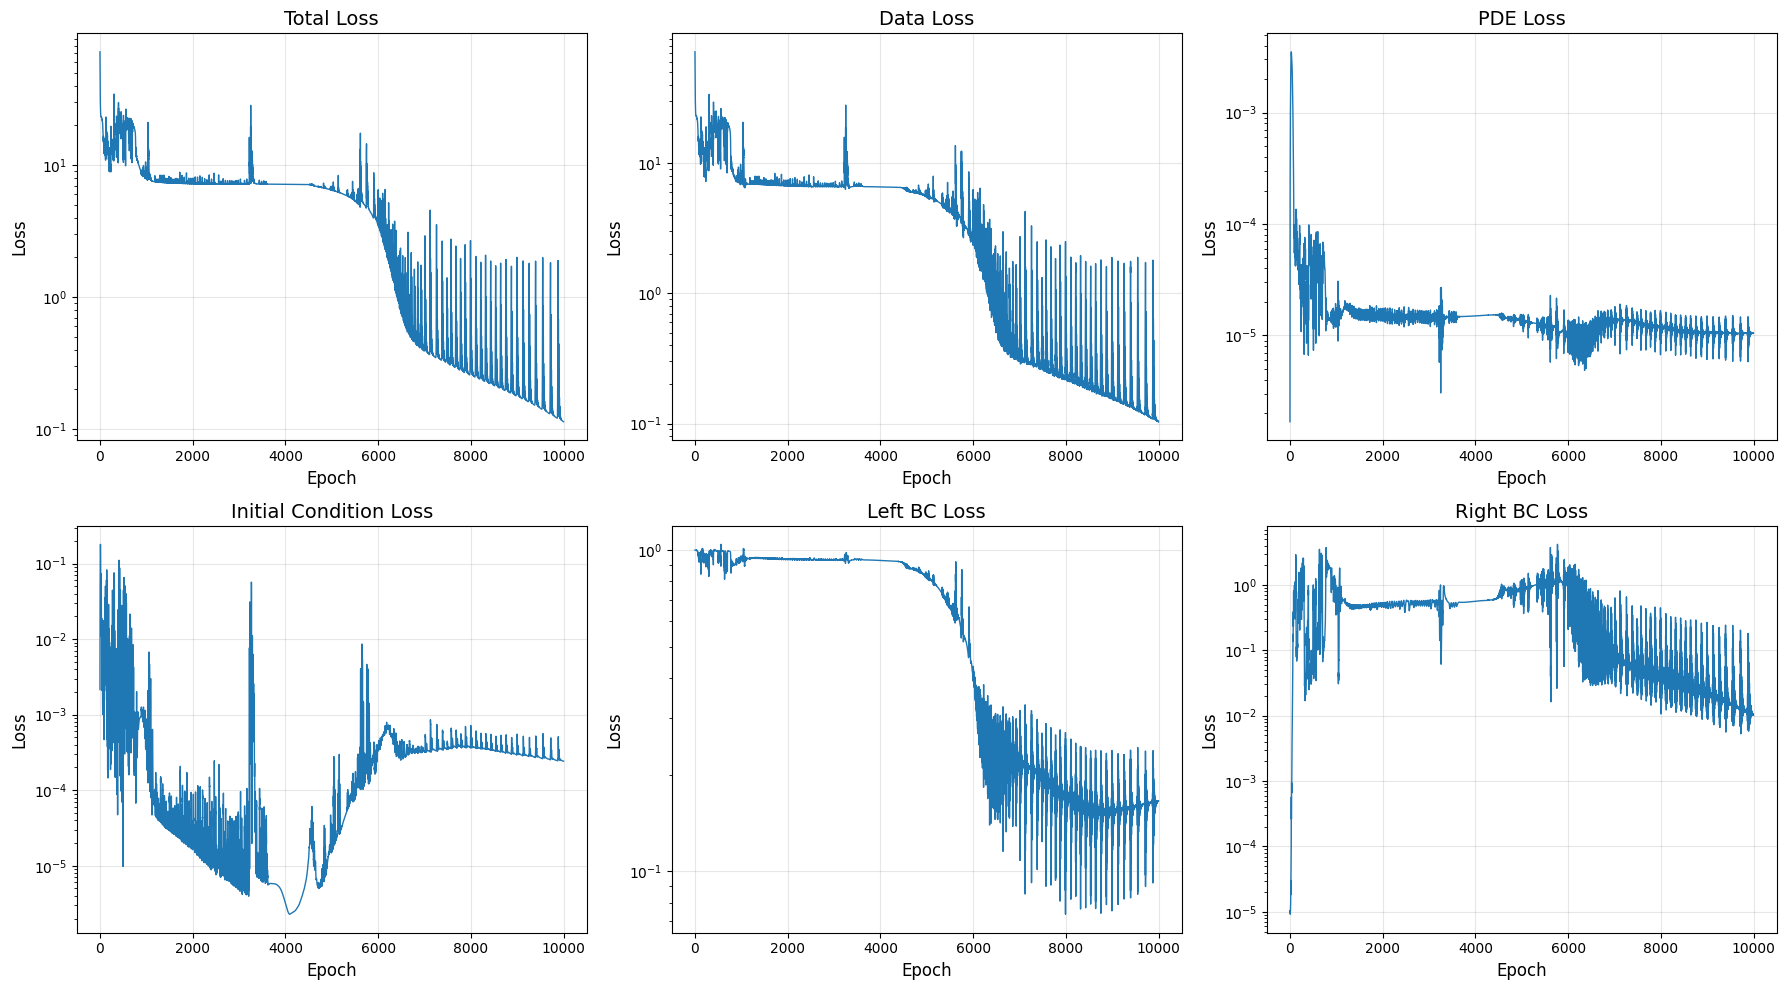

In [7]:
# Cell 12: Plot training history
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

loss_names = ['total', 'data', 'pde', 'ic', 'bc_left', 'bc_right']
titles = ['Total Loss', 'Data Loss', 'PDE Loss',
          'Initial Condition Loss', 'Left BC Loss', 'Right BC Loss']

for idx, (loss_name, title) in enumerate(zip(loss_names, titles)):
    ax = axes[idx // 3, idx % 3]
    ax.plot(history[loss_name], linewidth=1)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Cell 13: Load best model and evaluate
model.load_state_dict(torch.load('/content/best_pinn_model.pth'))
model.eval()

# Create dense grid for prediction
nx_pred = 500
nt_pred = 500
x_pred = np.linspace(0, L, nx_pred)
t_pred = np.linspace(0, 3600, nt_pred)

X_pred, T_time_pred = np.meshgrid(x_pred, t_pred)
x_flat = X_pred.flatten()
t_flat = T_time_pred.flatten()

# Predict on dense grid
with torch.no_grad():
    x_tensor = torch.FloatTensor(x_flat).reshape(-1, 1).to(device)
    t_tensor = torch.FloatTensor(t_flat).reshape(-1, 1).to(device)

    T_pred_flat = model(x_tensor, t_tensor).cpu().numpy()

T_pred_field = T_pred_flat.reshape(nt_pred, nx_pred)

print(f"Prediction completed!")
print(f"Predicted temperature range: [{T_pred_field.min():.2f}, {T_pred_field.max():.2f}] °C")

Prediction completed!
Predicted temperature range: [-0.02, 19.31] °C


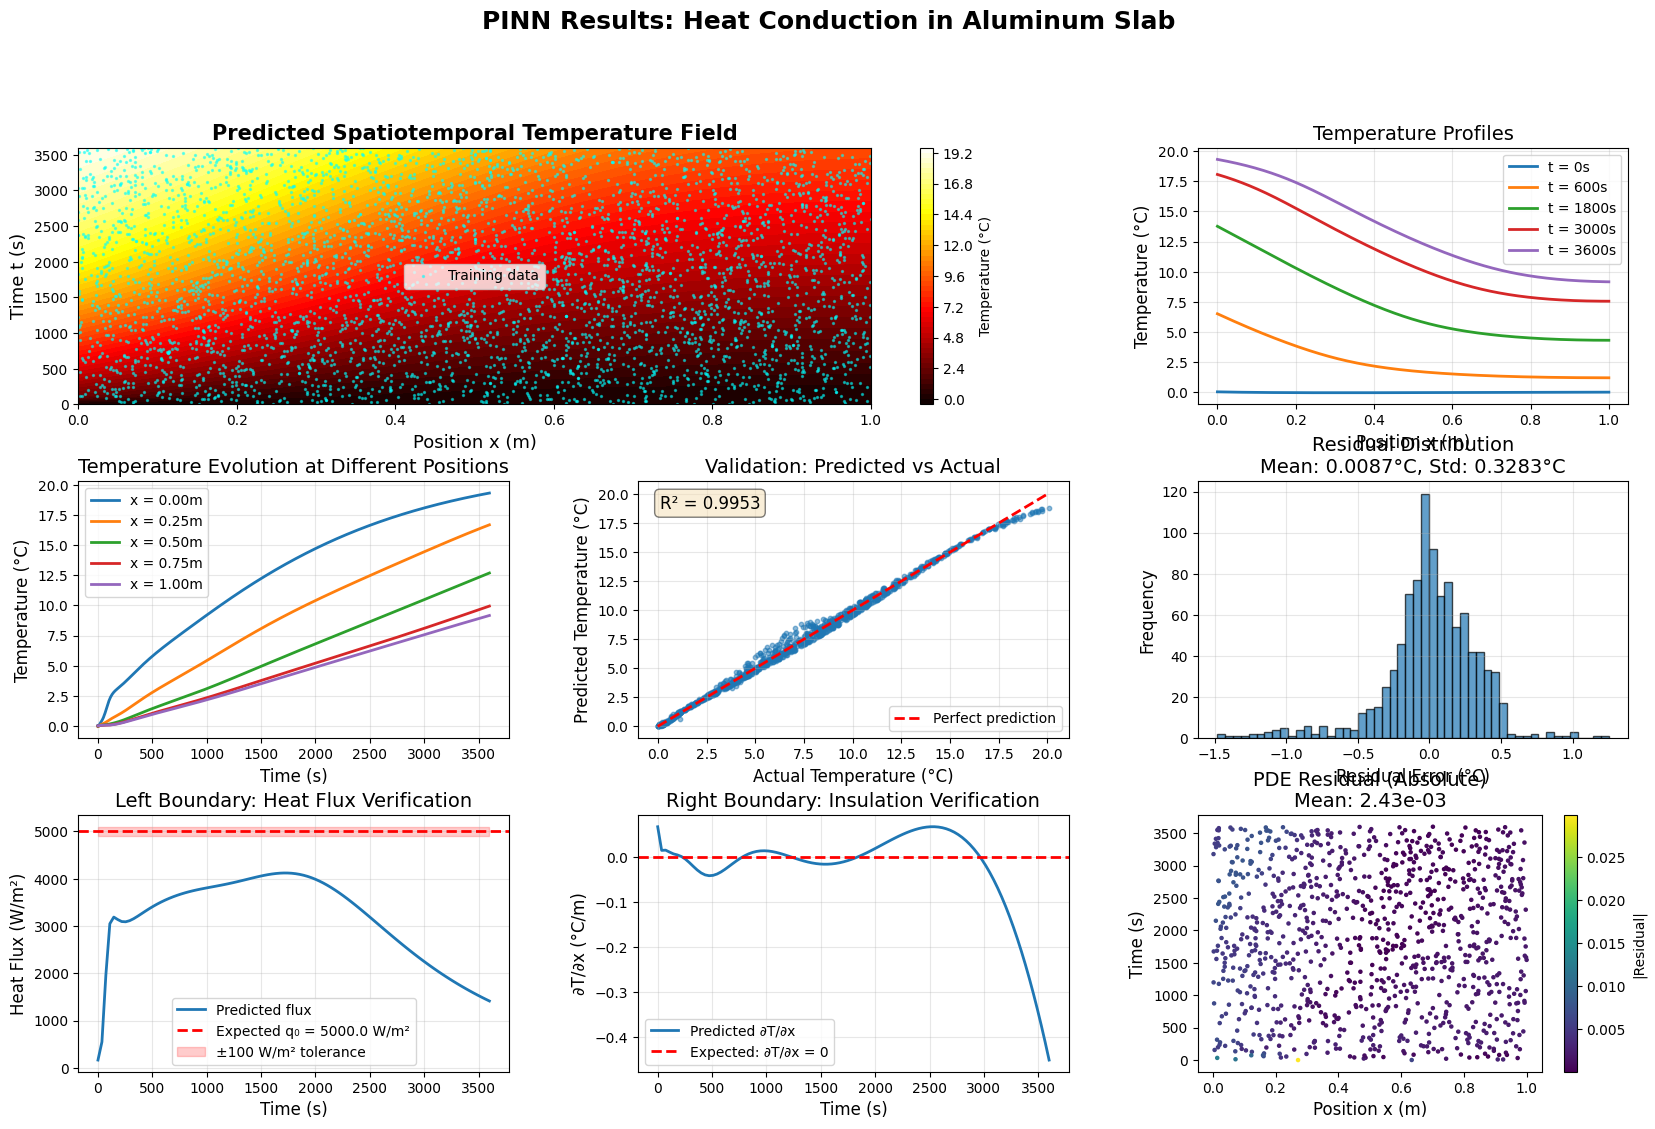


EVALUATION METRICS
R² Score (Validation): 0.995335
Mean Absolute Error: 0.230181 °C
Root Mean Square Error: 0.328451 °C
Max Absolute Error: 1.481892 °C
Mean PDE Residual: 2.430808e-03
Mean BC Left Flux Error: 1834.909058 W/m²
Mean BC Right Gradient: 5.519725e-02 °C/m


In [11]:
# Cell 14: Visualize results (CORRECTED)
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Spatiotemporal temperature field (predicted)
ax1 = fig.add_subplot(gs[0, :2])
c1 = ax1.contourf(X_pred, T_time_pred, T_pred_field, levels=50, cmap='hot')
ax1.scatter(pinn_data['x_train'], pinn_data['t_train'],
           c='cyan', s=2, alpha=0.5, label='Training data')
ax1.set_xlabel('Position x (m)', fontsize=13)
ax1.set_ylabel('Time t (s)', fontsize=13)
ax1.set_title('Predicted Spatiotemporal Temperature Field', fontsize=15, fontweight='bold')
plt.colorbar(c1, ax=ax1, label='Temperature (°C)')
ax1.legend()

# 2. Temperature profiles at different times
ax2 = fig.add_subplot(gs[0, 2])
times_to_show = [0, 600, 1800, 3000, 3600]
for t_val in times_to_show:
    t_idx = int((t_val / 3600) * (nt_pred - 1))
    ax2.plot(x_pred, T_pred_field[t_idx, :], label=f't = {t_val}s', linewidth=2)
ax2.set_xlabel('Position x (m)', fontsize=12)
ax2.set_ylabel('Temperature (°C)', fontsize=12)
ax2.set_title('Temperature Profiles', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Temperature evolution at different positions
ax3 = fig.add_subplot(gs[1, 0])
positions = [0.0, 0.25, 0.5, 0.75, 1.0]
for x_val in positions:
    x_idx = int(x_val * (nx_pred - 1))
    ax3.plot(t_pred, T_pred_field[:, x_idx], label=f'x = {x_val:.2f}m', linewidth=2)
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel('Temperature (°C)', fontsize=12)
ax3.set_title('Temperature Evolution at Different Positions', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Comparison: Predicted vs Actual (on validation data)
ax4 = fig.add_subplot(gs[1, 1])
with torch.no_grad():
    x_val_tensor = torch.FloatTensor(pinn_data['x_val']).reshape(-1, 1).to(device)
    t_val_tensor = torch.FloatTensor(pinn_data['t_val']).reshape(-1, 1).to(device)
    T_val_pred = model(x_val_tensor, t_val_tensor).cpu().numpy()

ax4.scatter(pinn_data['T_val'], T_val_pred, alpha=0.5, s=10)
min_T = min(pinn_data['T_val'].min(), T_val_pred.min())
max_T = max(pinn_data['T_val'].max(), T_val_pred.max())
ax4.plot([min_T, max_T], [min_T, max_T], 'r--', linewidth=2, label='Perfect prediction')
ax4.set_xlabel('Actual Temperature (°C)', fontsize=12)
ax4.set_ylabel('Predicted Temperature (°C)', fontsize=12)
ax4.set_title('Validation: Predicted vs Actual', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

# Calculate R² score
ss_res = np.sum((pinn_data['T_val'] - T_val_pred.flatten())**2)
ss_tot = np.sum((pinn_data['T_val'] - np.mean(pinn_data['T_val']))**2)
r2_score = 1 - (ss_res / ss_tot)
ax4.text(0.05, 0.95, f'R² = {r2_score:.4f}',
         transform=ax4.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 5. Residual error distribution
ax5 = fig.add_subplot(gs[1, 2])
residuals = pinn_data['T_val'] - T_val_pred.flatten()
ax5.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax5.set_xlabel('Residual Error (°C)', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title(f'Residual Distribution\nMean: {np.mean(residuals):.4f}°C, Std: {np.std(residuals):.4f}°C',
              fontsize=14)
ax5.grid(True, alpha=0.3)

# 6. Verify left boundary condition (heat flux)
# FIXED: Remove torch.no_grad() for gradient computation
ax6 = fig.add_subplot(gs[2, 0])
t_bc_test = np.linspace(0, 3600, 100)
x_bc_test = np.zeros(100)

model.eval()  # Set to eval mode
x_bc_tensor = torch.FloatTensor(x_bc_test).reshape(-1, 1).to(device).requires_grad_(True)
t_bc_tensor = torch.FloatTensor(t_bc_test).reshape(-1, 1).to(device)

T_bc = model(x_bc_tensor, t_bc_tensor)
T_x_bc = torch.autograd.grad(T_bc, x_bc_tensor, grad_outputs=torch.ones_like(T_bc),
                              create_graph=False)[0]

flux_pred = -k * T_x_bc.detach().cpu().numpy()

ax6.plot(t_bc_test, flux_pred, label='Predicted flux', linewidth=2)
ax6.axhline(y=q0, color='r', linestyle='--', linewidth=2, label=f'Expected q₀ = {q0} W/m²')
ax6.fill_between(t_bc_test, q0 - 100, q0 + 100, alpha=0.2, color='red', label='±100 W/m² tolerance')
ax6.set_xlabel('Time (s)', fontsize=12)
ax6.set_ylabel('Heat Flux (W/m²)', fontsize=12)
ax6.set_title('Left Boundary: Heat Flux Verification', fontsize=14)
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Verify right boundary condition (insulated)
# FIXED: Remove torch.no_grad() for gradient computation
ax7 = fig.add_subplot(gs[2, 1])
x_bc_right_test = np.ones(100) * L
t_bc_right_test = np.linspace(0, 3600, 100)

x_bc_r_tensor = torch.FloatTensor(x_bc_right_test).reshape(-1, 1).to(device).requires_grad_(True)
t_bc_r_tensor = torch.FloatTensor(t_bc_right_test).reshape(-1, 1).to(device)

T_bc_r = model(x_bc_r_tensor, t_bc_r_tensor)
T_x_bc_r = torch.autograd.grad(T_bc_r, x_bc_r_tensor, grad_outputs=torch.ones_like(T_bc_r),
                                create_graph=False)[0]

gradient_right = T_x_bc_r.detach().cpu().numpy()

ax7.plot(t_bc_right_test, gradient_right, linewidth=2, label='Predicted ∂T/∂x')
ax7.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Expected: ∂T/∂x = 0')
ax7.set_xlabel('Time (s)', fontsize=12)
ax7.set_ylabel('∂T/∂x (°C/m)', fontsize=12)
ax7.set_title('Right Boundary: Insulation Verification', fontsize=14)
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. PDE residual verification
# FIXED: Remove torch.no_grad() for gradient computation
ax8 = fig.add_subplot(gs[2, 2])
n_check = 1000
x_check = np.random.uniform(0, L, n_check)
t_check = np.random.uniform(0, 3600, n_check)

x_check_tensor = torch.FloatTensor(x_check).reshape(-1, 1).to(device)
t_check_tensor = torch.FloatTensor(t_check).reshape(-1, 1).to(device)

pde_res, _ = compute_pde_residual(model, x_check_tensor, t_check_tensor, alpha)
pde_res_np = pde_res.detach().cpu().numpy()

ax8.scatter(x_check, t_check, c=np.abs(pde_res_np), s=5, cmap='viridis')
ax8.set_xlabel('Position x (m)', fontsize=12)
ax8.set_ylabel('Time (s)', fontsize=12)
ax8.set_title(f'PDE Residual (Absolute)\nMean: {np.mean(np.abs(pde_res_np)):.2e}', fontsize=14)
plt.colorbar(ax8.collections[0], ax=ax8, label='|Residual|')

plt.suptitle('PINN Results: Heat Conduction in Aluminum Slab',
             fontsize=18, fontweight='bold', y=0.995)
plt.savefig('/content/pinn_results_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("EVALUATION METRICS")
print("="*70)
print(f"R² Score (Validation): {r2_score:.6f}")
print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.6f} °C")
print(f"Root Mean Square Error: {np.sqrt(np.mean(residuals**2)):.6f} °C")
print(f"Max Absolute Error: {np.max(np.abs(residuals)):.6f} °C")
print(f"Mean PDE Residual: {np.mean(np.abs(pde_res_np)):.6e}")
print(f"Mean BC Left Flux Error: {np.mean(np.abs(flux_pred - q0)):.6f} W/m²")
print(f"Mean BC Right Gradient: {np.mean(np.abs(gradient_right)):.6e} °C/m")
print("="*70)

Full dataset loaded: 5000 points


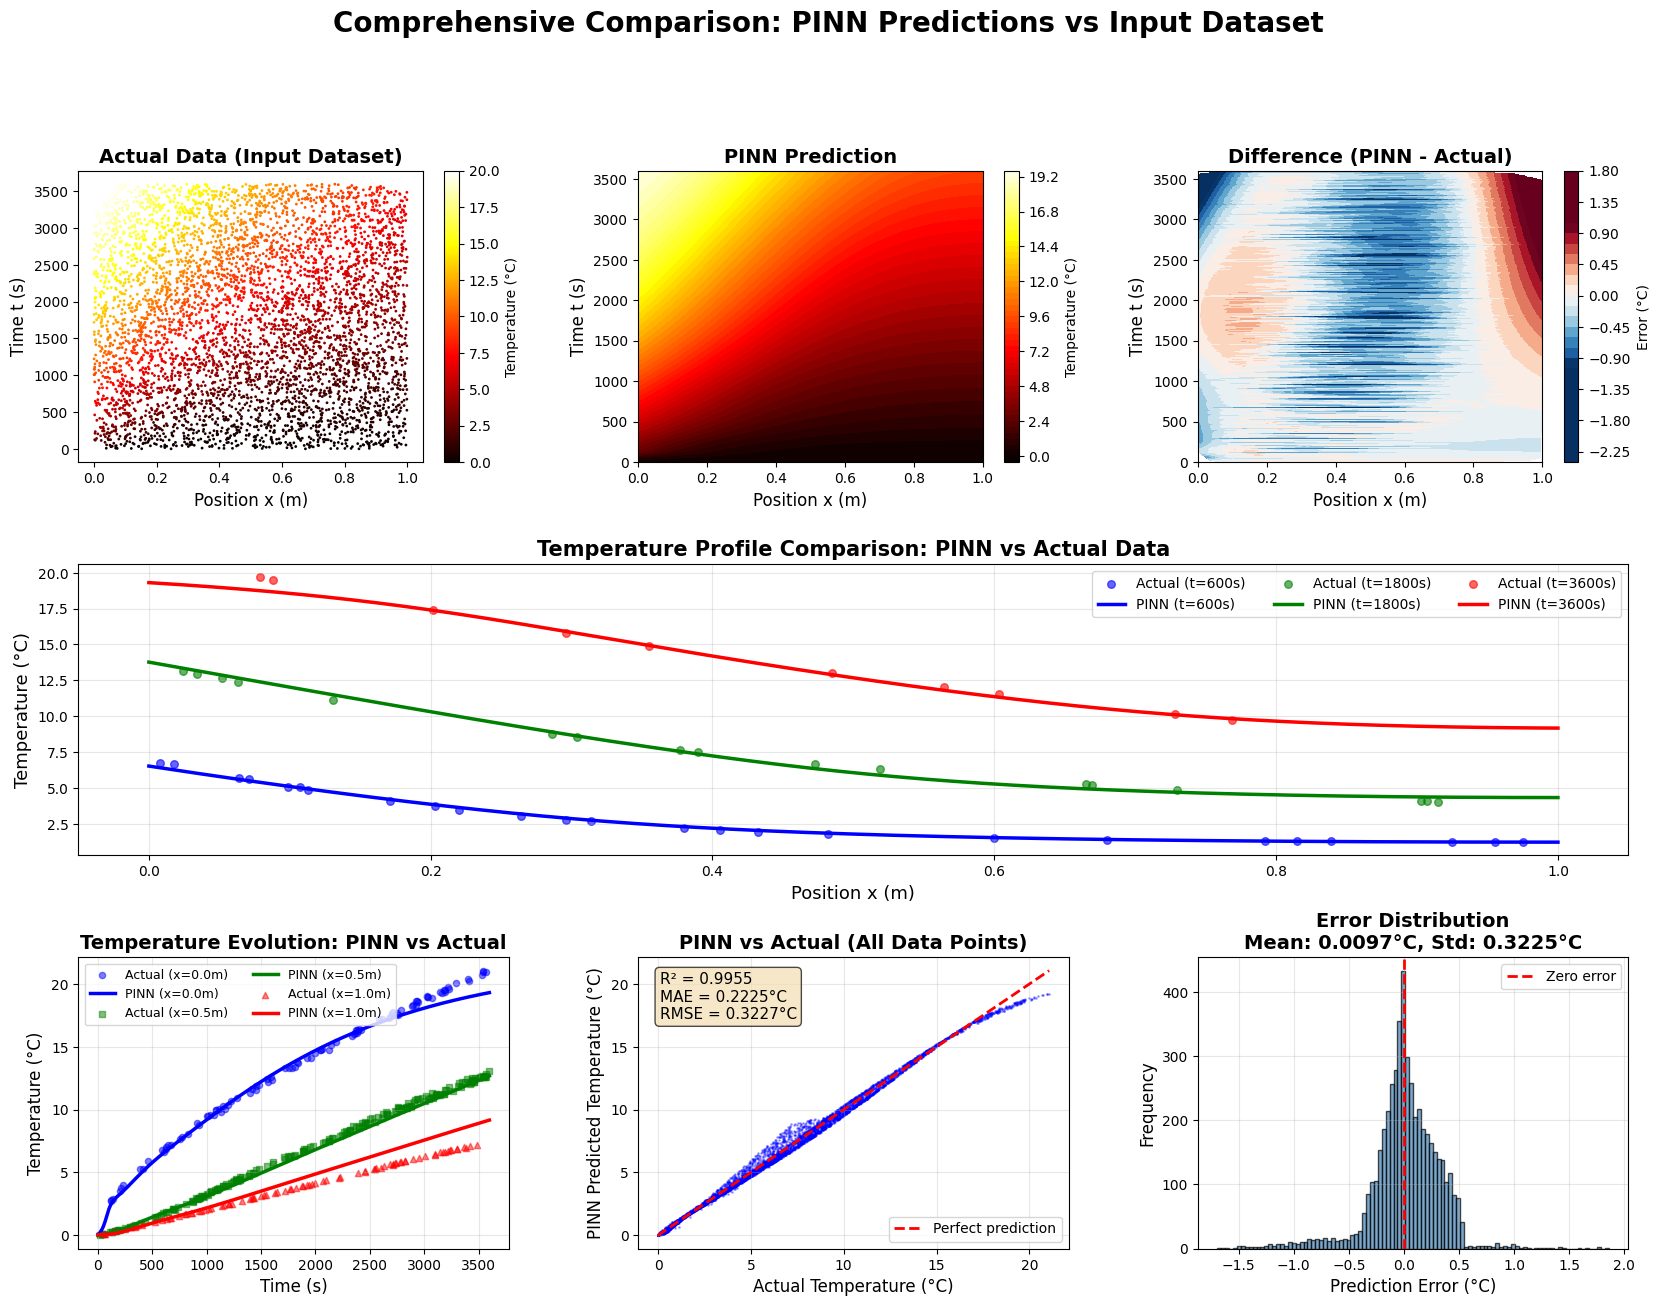


COMPREHENSIVE COMPARISON: PINN vs ACTUAL INPUT DATA
Total data points compared: 5,000

Prediction Accuracy:
  R² Score:                0.995523
  Mean Absolute Error:     0.222476 °C
  Root Mean Square Error:  0.322682 °C
  Max Absolute Error:      1.859876 °C
  Mean Error (Bias):       0.009658 °C
  Std Dev of Errors:       0.322537 °C

Error Percentiles:
  5th percentile:          0.010119 °C
  25th percentile:         0.063514 °C
  50th percentile (median):0.158689 °C
  75th percentile:         0.303088 °C
  95th percentile:         0.685882 °C
  99th percentile:         1.190118 °C


In [12]:
# Cell 15: Comprehensive Comparison - PINN vs Actual Data
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Load the original full dataset for comparison
df_full = pd.read_csv("/content/data_sampled.csv")
x_full = df_full['x'].values if 'x' in df_full.columns else df_full.iloc[:, 0].values
t_full = df_full['t'].values if 't' in df_full.columns else df_full.iloc[:, 1].values
T_full = df_full['T'].values if 'T' in df_full.columns else df_full.iloc[:, 2].values

print(f"Full dataset loaded: {len(x_full)} points")

# ============================================================================
# 1. Side-by-side spatiotemporal comparison
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
scatter1 = ax1.scatter(x_full, t_full, c=T_full, s=1, cmap='hot', vmin=0, vmax=20)
ax1.set_xlabel('Position x (m)', fontsize=12)
ax1.set_ylabel('Time t (s)', fontsize=12)
ax1.set_title('Actual Data (Input Dataset)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Temperature (°C)')

ax2 = fig.add_subplot(gs[0, 1])
c2 = ax2.contourf(X_pred, T_time_pred, T_pred_field, levels=50, cmap='hot', vmin=0, vmax=20)
ax2.set_xlabel('Position x (m)', fontsize=12)
ax2.set_ylabel('Time t (s)', fontsize=12)
ax2.set_title('PINN Prediction', fontsize=14, fontweight='bold')
plt.colorbar(c2, ax=ax2, label='Temperature (°C)')

# Compute difference on a common grid
ax3 = fig.add_subplot(gs[0, 2])
# Interpolate actual data onto prediction grid for fair comparison
from scipy.interpolate import griddata
T_actual_interpolated = griddata((x_full, t_full), T_full, (X_pred, T_time_pred), method='linear')
difference = T_pred_field - T_actual_interpolated
c3 = ax3.contourf(X_pred, T_time_pred, difference, levels=30, cmap='RdBu_r',
                  vmin=-1, vmax=1)
ax3.set_xlabel('Position x (m)', fontsize=12)
ax3.set_ylabel('Time t (s)', fontsize=12)
ax3.set_title('Difference (PINN - Actual)', fontsize=14, fontweight='bold')
plt.colorbar(c3, ax=ax3, label='Error (°C)')

# ============================================================================
# 2. Temperature profiles comparison at specific times
# ============================================================================
ax4 = fig.add_subplot(gs[1, :])
times_compare = [600, 1800, 3600]
colors = ['blue', 'green', 'red']

for idx, (t_val, color) in enumerate(zip(times_compare, colors)):
    # Actual data at this time
    mask_actual = np.abs(t_full - t_val) < 10  # Within 10 seconds
    x_actual = x_full[mask_actual]
    T_actual = T_full[mask_actual]

    # Sort for proper plotting
    sort_idx = np.argsort(x_actual)

    # PINN prediction at this time
    t_idx = int((t_val / 3600) * (nt_pred - 1))

    # Plot
    ax4.scatter(x_actual[sort_idx], T_actual[sort_idx],
               color=color, s=30, alpha=0.6, label=f'Actual (t={t_val}s)', marker='o')
    ax4.plot(x_pred, T_pred_field[t_idx, :],
            color=color, linewidth=2.5, label=f'PINN (t={t_val}s)', linestyle='-')

ax4.set_xlabel('Position x (m)', fontsize=13)
ax4.set_ylabel('Temperature (°C)', fontsize=13)
ax4.set_title('Temperature Profile Comparison: PINN vs Actual Data', fontsize=15, fontweight='bold')
ax4.legend(ncol=3, fontsize=10)
ax4.grid(True, alpha=0.3)

# ============================================================================
# 3. Temperature evolution comparison at specific positions
# ============================================================================
ax5 = fig.add_subplot(gs[2, 0])
positions_compare = [0.0, 0.5, 1.0]
colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']

for idx, (x_val, color, marker) in enumerate(zip(positions_compare, colors, markers)):
    # Actual data at this position
    mask_actual = np.abs(x_full - x_val) < 0.02  # Within 2cm
    t_actual = t_full[mask_actual]
    T_actual = T_full[mask_actual]

    # Sort for proper plotting
    sort_idx = np.argsort(t_actual)

    # PINN prediction at this position
    x_idx = int(x_val * (nx_pred - 1))

    # Plot
    ax5.scatter(t_actual[sort_idx], T_actual[sort_idx],
               color=color, s=20, alpha=0.5, label=f'Actual (x={x_val:.1f}m)', marker=marker)
    ax5.plot(t_pred, T_pred_field[:, x_idx],
            color=color, linewidth=2.5, label=f'PINN (x={x_val:.1f}m)', linestyle='-')

ax5.set_xlabel('Time (s)', fontsize=12)
ax5.set_ylabel('Temperature (°C)', fontsize=12)
ax5.set_title('Temperature Evolution: PINN vs Actual', fontsize=14, fontweight='bold')
ax5.legend(ncol=2, fontsize=9)
ax5.grid(True, alpha=0.3)

# ============================================================================
# 4. Direct comparison scatter plot (all data points)
# ============================================================================
ax6 = fig.add_subplot(gs[2, 1])

# Get PINN predictions at all actual data points
with torch.no_grad():
    x_full_tensor = torch.FloatTensor(x_full).reshape(-1, 1).to(device)
    t_full_tensor = torch.FloatTensor(t_full).reshape(-1, 1).to(device)
    T_full_pred = model(x_full_tensor, t_full_tensor).cpu().numpy().flatten()

# Scatter plot
ax6.scatter(T_full, T_full_pred, alpha=0.3, s=1, c='blue')
min_T_comp = min(T_full.min(), T_full_pred.min())
max_T_comp = max(T_full.max(), T_full_pred.max())
ax6.plot([min_T_comp, max_T_comp], [min_T_comp, max_T_comp],
        'r--', linewidth=2, label='Perfect prediction')

# Calculate metrics
r2_full = 1 - np.sum((T_full - T_full_pred)**2) / np.sum((T_full - np.mean(T_full))**2)
mae_full = np.mean(np.abs(T_full - T_full_pred))
rmse_full = np.sqrt(np.mean((T_full - T_full_pred)**2))

ax6.set_xlabel('Actual Temperature (°C)', fontsize=12)
ax6.set_ylabel('PINN Predicted Temperature (°C)', fontsize=12)
ax6.set_title('PINN vs Actual (All Data Points)', fontsize=14, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)
ax6.text(0.05, 0.95,
         f'R² = {r2_full:.4f}\nMAE = {mae_full:.4f}°C\nRMSE = {rmse_full:.4f}°C',
         transform=ax6.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# ============================================================================
# 5. Error distribution across space and time
# ============================================================================
ax7 = fig.add_subplot(gs[2, 2])
errors_full = T_full - T_full_pred
ax7.hist(errors_full, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax7.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax7.set_xlabel('Prediction Error (°C)', fontsize=12)
ax7.set_ylabel('Frequency', fontsize=12)
ax7.set_title(f'Error Distribution\nMean: {np.mean(errors_full):.4f}°C, Std: {np.std(errors_full):.4f}°C',
              fontsize=14, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Comparison: PINN Predictions vs Input Dataset',
             fontsize=20, fontweight='bold', y=0.995)
plt.savefig('/content/pinn_vs_actual_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# Print detailed comparison statistics
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: PINN vs ACTUAL INPUT DATA")
print("="*80)
print(f"Total data points compared: {len(T_full):,}")
print(f"\nPrediction Accuracy:")
print(f"  R² Score:                {r2_full:.6f}")
print(f"  Mean Absolute Error:     {mae_full:.6f} °C")
print(f"  Root Mean Square Error:  {rmse_full:.6f} °C")
print(f"  Max Absolute Error:      {np.max(np.abs(errors_full)):.6f} °C")
print(f"  Mean Error (Bias):       {np.mean(errors_full):.6f} °C")
print(f"  Std Dev of Errors:       {np.std(errors_full):.6f} °C")
print(f"\nError Percentiles:")
print(f"  5th percentile:          {np.percentile(np.abs(errors_full), 5):.6f} °C")
print(f"  25th percentile:         {np.percentile(np.abs(errors_full), 25):.6f} °C")
print(f"  50th percentile (median):{np.percentile(np.abs(errors_full), 50):.6f} °C")
print(f"  75th percentile:         {np.percentile(np.abs(errors_full), 75):.6f} °C")
print(f"  95th percentile:         {np.percentile(np.abs(errors_full), 95):.6f} °C")
print(f"  99th percentile:         {np.percentile(np.abs(errors_full), 99):.6f} °C")
print("="*80)

In [13]:
# Cell: Generate Loss Function Table with Real Values

print("="*80)
print("LOSS FUNCTION CONFIGURATION - ACTUAL VALUES FROM YOUR TRAINING")
print("="*80)

# Get actual sample sizes
n_train = len(pinn_data['x_train'])
n_val = len(pinn_data['x_val'])
n_pde_collocation = len(pinn_data['x_col'])
n_ic_points = len(pinn_data['x_ic'])
n_bc_left = len(pinn_data['x_bc_left'])
n_bc_right = len(pinn_data['x_bc_right'])

# Get actual weights from your training
actual_weights = weights  # This is from your Cell 10

print(f"\nData Configuration:")
print(f"  Total training measurements: {n_train}")
print(f"  Total validation measurements: {n_val}")
print(f"  PDE collocation points: {n_pde_collocation}")
print(f"  Initial condition points: {n_ic_points}")
print(f"  Left boundary points: {n_bc_left}")
print(f"  Right boundary points: {n_bc_right}")

print(f"\nLoss Weights:")
for key, value in actual_weights.items():
    print(f"  {key}: {value}")

# Create formatted table
print("\n" + "="*80)
print("TABLE 1: LOSS FUNCTION COMPONENTS AND CONFIGURATION")
print("="*80)
print(f"{'Loss Component':<18} {'Expression':<35} {'Weight':<10} {'Sample Size':<15}")
print("-" * 80)
print(f"{'Data (L_data)':<18} {'(1/N) Σ(T_θ - T_measured)²':<35} {actual_weights['data']:<10.1f} {n_train:<15}")
print(f"{'PDE (L_PDE)':<18} {'(1/N) Σ(∂T/∂t - α∂²T/∂x²)²':<35} {actual_weights['pde']:<10.1f} {n_pde_collocation:<15,}")
print(f"{'Initial (L_IC)':<18} {'(1/N) Σ(T_θ(x,0))²':<35} {actual_weights['ic']:<10.1f} {n_ic_points:<15}")
print(f"{'BC Left':<18} {'(1/N) Σ[(-k∂T/∂x - q_0)/q_0]²':<35} {actual_weights['bc_left']:<10.1f} {n_bc_left:<15}")
print(f"{'BC Right':<18} {'(1/N) Σ(∂T/∂x)²':<35} {actual_weights['bc_right']:<10.1f} {n_bc_right:<15}")
print("=" * 80)

# Additional useful information
print(f"\nPhysical Parameters:")
print(f"  Thermal diffusivity (α): {alpha:.6e} m²/s")
print(f"  Thermal conductivity (k): {k:.1f} W/(m·K)")
print(f"  Applied heat flux (q₀): {q0:.1f} W/m²")
print(f"  Domain length (L): {L:.1f} m")
print(f"  Time horizon: 3600 s (1 hour)")

# Calculate data coverage
total_full_dataset = len(df)
data_coverage = 100 * (n_train + n_val) / total_full_dataset

print(f"\nData Utilization:")
print(f"  Full dataset size: {total_full_dataset:,} points")
print(f"  Used for training: {n_train} points ({100*n_train/total_full_dataset:.2f}%)")
print(f"  Used for validation: {n_val} points ({100*n_val/total_full_dataset:.2f}%)")
print(f"  Total data coverage: {data_coverage:.2f}%")

print("="*80)

LOSS FUNCTION CONFIGURATION - ACTUAL VALUES FROM YOUR TRAINING

Data Configuration:
  Total training measurements: 4000
  Total validation measurements: 1000
  PDE collocation points: 10000
  Initial condition points: 200
  Left boundary points: 200
  Right boundary points: 200

Loss Weights:
  data: 1.0
  pde: 1.0
  ic: 1.0
  bc_left: 1e-06
  bc_right: 1.0

TABLE 1: LOSS FUNCTION COMPONENTS AND CONFIGURATION
Loss Component     Expression                          Weight     Sample Size    
--------------------------------------------------------------------------------
Data (L_data)      (1/N) Σ(T_θ - T_measured)²          1.0        4000           
PDE (L_PDE)        (1/N) Σ(∂T/∂t - α∂²T/∂x²)²          1.0        10,000         
Initial (L_IC)     (1/N) Σ(T_θ(x,0))²                  1.0        200            
BC Left            (1/N) Σ[(-k∂T/∂x - q_0)/q_0]²       0.0        200            
BC Right           (1/N) Σ(∂T/∂x)²                     1.0        200            

Physical Para